## Overview

* dropout
* early stopping
* weight decay

### Package Importing

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from torch import nn
import torch
from torch.utils.data import DataLoader,TensorDataset
torch.manual_seed(50)
generator=torch.manual_seed(50)

### Data Preprocessing

In [4]:
data=load_iris()
x=torch.tensor(data.data,dtype=torch.float32)
y=torch.tensor(data.target,dtype=torch.long)
print(x.shape)
print(y.shape)
train_x,temp_x,train_y,temp_y=train_test_split(x,y,test_size=0.3,random_state=50)
val_x,test_x,val_y,test_y=train_test_split(temp_x,temp_y,test_size=0.5,random_state=50)
print(train_x.shape,train_y.shape)
dataset=TensorDataset(train_x,train_y)
loader=DataLoader(dataset,shuffle=True,batch_size=10)

torch.Size([150, 4])
torch.Size([150])
torch.Size([105, 4]) torch.Size([105])


### Model

In [ ]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(4,30)
        self.layer2=nn.Linear(30,5)
        self.layer3=nn.Linear(5,3)
        self.dropout=nn.Dropout(p=0.3)
    def forward(self,x):
        x=self.layer1(x)
        x=torch.sigmoid(x)
        x=self.dropout(x)
        x=self.layer2(x)
        x=torch.sigmoid(x)
        x=self.dropout(x)
        x=self.layer3(x)
        x=torch.sigmoid(x)
        return x

### Training, Validation and Testing

In [11]:
epoch=600
model=Network()
optimizer=torch.optim.SGD(model.parameters(),lr=0.3,weight_decay=0.001)
loss_fn=nn.CrossEntropyLoss()
val_best=float('inf')
earlystoppinglimit=5
for i in range(epoch):
    model.train()
    loss=0
    validation_loss=0
    for batch_data,actual_result in loader:
        optimizer.zero_grad()
        predicted_result=model.forward(batch_data)
        batch_loss=loss_fn(predicted_result,actual_result)
        batch_loss.backward()
        optimizer.step()
        loss+=batch_loss.item()
    with torch.no_grad():
        model.eval()
        predicted_val=model.forward(val_x)
        validation_loss=loss_fn(predicted_val,val_y).item()
    if i%30==0:
        if validation_loss<val_best:
            val_best=validation_loss
            log=True
            earlystopping=0
        else:
            log=False
            earlystopping+=1
        if earlystopping>=earlystoppinglimit:
            print(f"Stopped at {i}")
            break
        print(f"Training Loss: {loss/len(loader)}    validation Loss: {log}")
with torch.no_grad():
    model.eval()
    test_result=model(test_x)
    test_loss=loss_fn(test_result,test_y)
    print(test_loss.item())

Training Loss: 1.1044629378752275    validation Loss: True
Training Loss: 1.0333959622816606    validation Loss: True
Training Loss: 0.8062540780414235    validation Loss: True
Training Loss: 0.7794935703277588    validation Loss: True
Training Loss: 0.774872980334542    validation Loss: True
Training Loss: 0.7672115781090476    validation Loss: True
Training Loss: 0.7566463242877614    validation Loss: True
Training Loss: 0.7442569895224138    validation Loss: True
Training Loss: 0.7340186780149286    validation Loss: True
Training Loss: 0.7260312221267007    validation Loss: True
Training Loss: 0.7217383059588346    validation Loss: True
Training Loss: 0.7164453972469677    validation Loss: True
Training Loss: 0.7102887576276605    validation Loss: True
Training Loss: 0.7123693932186473    validation Loss: True
Training Loss: 0.7131060470234264    validation Loss: True
Training Loss: 0.7091853835365989    validation Loss: True
Training Loss: 0.7049032937396656    validation Loss: Fal

### Visualisation

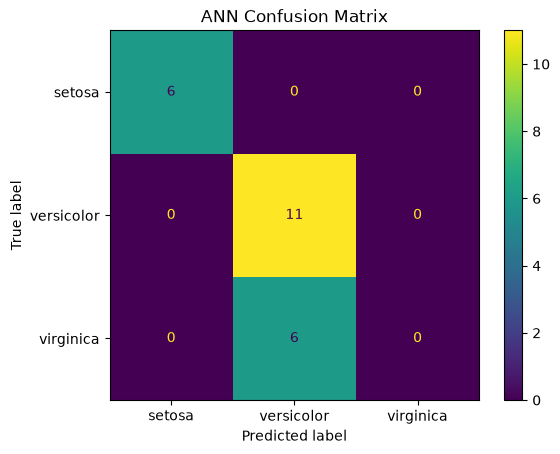

In [7]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
predicted_class = torch.argmax(test_result, dim=1)
cm = confusion_matrix(test_y.numpy(),predicted_class.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=data.target_names)
disp.plot()
plt.title("ANN Confusion Matrix")
plt.show()
